In [1]:
import cv2
import os
import matplotlib.pyplot as plt

In [2]:
input_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\grayscale_frames\match1"
output_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\denoised_frames\match1"

os.makedirs(output_folder, exist_ok=True)

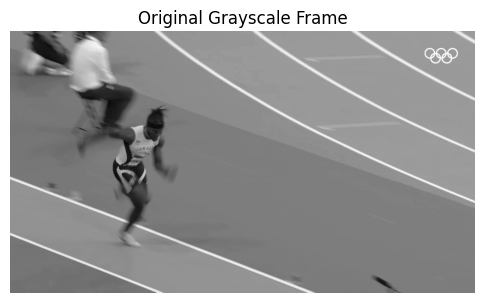

In [3]:
sample_path = os.path.join(input_folder, "frame_0000.jpg")
img = cv2.imread(sample_path, 0)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Frame")
plt.axis("off")
plt.show()

In [4]:
gaussian_denoised = cv2.GaussianBlur(img, (5, 5), 0)
median_denoised = cv2.medianBlur(img, 5)
bilateral_denoised = cv2.bilateralFilter(img, 9, 75, 75)
nlm_denoised = cv2.fastNlMeansDenoising(img, None, 10, 7, 21)

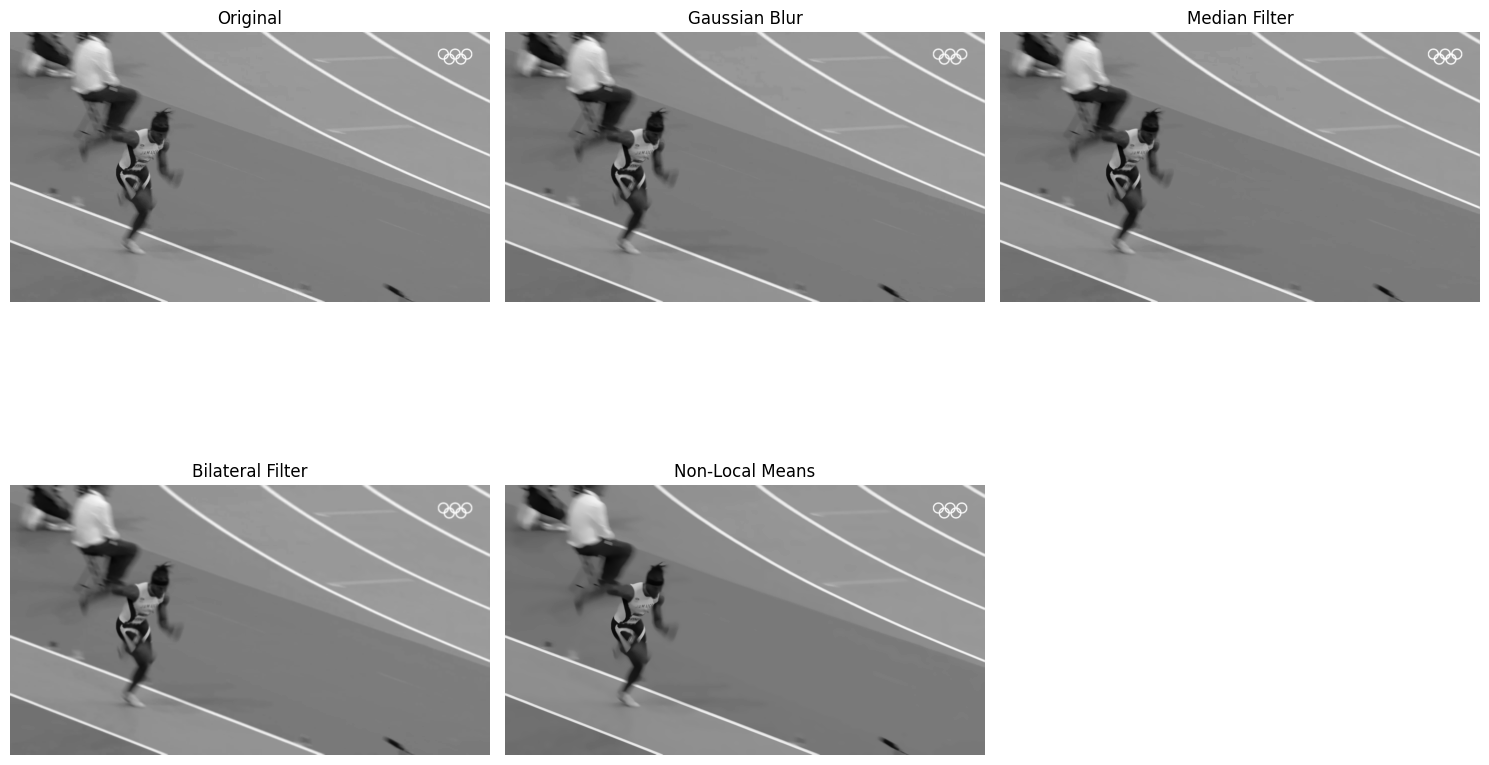

In [5]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gaussian_denoised, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(median_denoised, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(bilateral_denoised, cmap="gray")
plt.title("Bilateral Filter")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(nlm_denoised, cmap="gray")
plt.title("Non-Local Means")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
frame_files = sorted(os.listdir(input_folder))

for file in frame_files:
    if file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg"):
        path = os.path.join(input_folder, file)
        img = cv2.imread(path, 0)

        denoised = cv2.fastNlMeansDenoising(img, None, 10, 7, 21)

        save_path = os.path.join(output_folder, file)
        cv2.imwrite(save_path, denoised)

print("Denoised frames saved successfully.")

Denoised frames saved successfully.


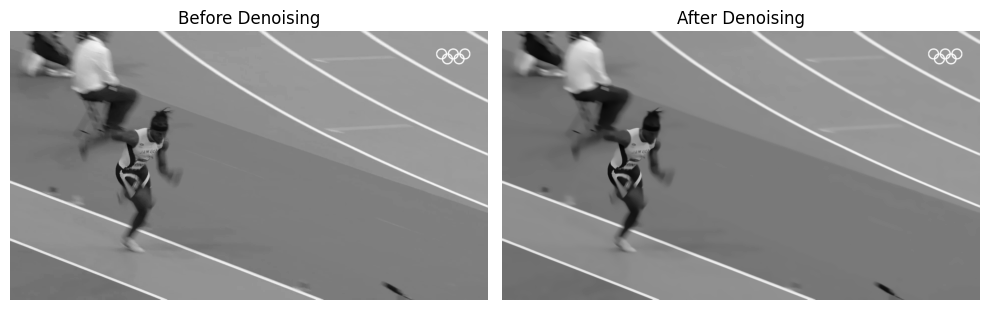

In [8]:
frame_name = "frame_0000.jpg"

original_path = os.path.join(input_folder, frame_name)
denoised_path = os.path.join(output_folder, frame_name)

# read images
original = cv2.imread(original_path, 0)
denoised = cv2.imread(denoised_path, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap="gray")
plt.title("Before Denoising")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denoised, cmap="gray")
plt.title("After Denoising")
plt.axis("off")

plt.tight_layout()
plt.show()